

# **Dataset Overview**

The Dry Bean Dataset contains measurements of physical characteristics of seven types of dry beans, captured from digital images. It describes each bean using shape and morphological features such as area, perimeter, and compactness.

The goal in this analysis is to use KMeans clustering to group beans based on their physical features. While the actual bean type labels are available, they are only used to evaluate how well the clustering captures meaningful class distinctions, not for training or prediction.

## **Source:**

Available via the UCI Machine Learning Repository:[UCI Dataset Page](https://archive.ics.uci.edu/ml/datasets/Dry+Bean+Dataset)


## **Features:**

| Column Name     | Description                                               | Data Type       |
| --------------- | --------------------------------------------------------- | --------------- |
| Area            | Total number of pixels in the region                      | Numeric (float) |
| Perimeter       | Circumference of the bean region                          | Numeric (float) |
| MajorAxisLength | Length of the major axis of the fitted ellipse            | Numeric (float) |
| MinorAxisLength | Length of the minor axis of the fitted ellipse            | Numeric (float) |
| AspectRation    | Ratio of major axis to minor axis                         | Numeric (float) |
| Eccentricity    | Eccentricity of the ellipse (how elongated the shape is)  | Numeric (float) |
| ConvexArea      | Number of pixels in the convex hull region                | Numeric (float) |
| EquivDiameter   | Diameter of a circle with the same area as the region     | Numeric (float) |
| Extent          | Ratio of region area to bounding box area                 | Numeric (float) |
| Solidity        | Ratio of region area to convex hull area                  | Numeric (float) |
| Roundness       | Shape roundness based on area and perimeter               | Numeric (float) |
| Compactness     | How closely the bean shape resembles a circle             | Numeric (float) |
| ShapeFactor1    | Shape descriptor based on perimeter and area              | Numeric (float) |
| ShapeFactor2    | Shape descriptor based on perimeter and major axis length | Numeric (float) |
| ShapeFactor3    | Shape descriptor based on area and bounding box           | Numeric (float) |
| ShapeFactor4    | Another derived shape descriptor                          | Numeric (float) |
| Class           | Bean type label (e.g., Seker, Barbunya, Bombay, etc.)              | Categorical      |


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# **Loading the data**

In [4]:
df_beans=pd.read_excel('Dry_Bean_Dataset.xlsx')
print(df_beans.shape)
df_beans

(13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13606,42097,759.696,288.721612,185.944705,1.552728,0.765002,42508,231.515799,0.714574,0.990331,0.916603,0.801865,0.006858,0.001749,0.642988,0.998385,DERMASON
13607,42101,757.499,281.576392,190.713136,1.476439,0.735702,42494,231.526798,0.799943,0.990752,0.922015,0.822252,0.006688,0.001886,0.676099,0.998219,DERMASON
13608,42139,759.321,281.539928,191.187979,1.472582,0.734065,42569,231.631261,0.729932,0.989899,0.918424,0.822730,0.006681,0.001888,0.676884,0.996767,DERMASON
13609,42147,763.779,283.382636,190.275731,1.489326,0.741055,42667,231.653248,0.705389,0.987813,0.907906,0.817457,0.006724,0.001852,0.668237,0.995222,DERMASON


In [5]:
df_beans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

# **Checking explicitly for Missing Values**

In [6]:
df_beans.isnull().sum()

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

# **Descriptive Statistics of Numerical Attributes**

In [7]:
df_beans.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


# **Duplicate values in Dataset**

In [8]:
print(f'Duplicate rows in the datsaset :{df_beans.duplicated().sum()}\n')

print('Bean type of duplicated rows:')
print(df_beans[df_beans.duplicated()].Class.value_counts())


print('\nDisplaying the duplicated rows')
df_beans[df_beans.duplicated(keep=False)]

Duplicate rows in the datsaset :68

Bean type of duplicated rows:
Class
HOROZ    68
Name: count, dtype: int64

Displaying the duplicated rows


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
5504,33518,702.956,277.571399,154.305581,1.798842,0.831240,34023,206.582775,0.808383,0.985157,0.852377,0.744251,0.008281,0.001567,0.553909,0.996396,HOROZ
5505,33518,702.956,277.571399,154.305581,1.798842,0.831240,34023,206.582775,0.808383,0.985157,0.852377,0.744251,0.008281,0.001567,0.553909,0.996396,HOROZ
5508,33954,716.750,277.368480,156.356326,1.773951,0.825970,34420,207.922042,0.799482,0.986461,0.830549,0.749624,0.008169,0.001591,0.561936,0.996847,HOROZ
5509,33954,716.750,277.368480,156.356326,1.773951,0.825970,34420,207.922042,0.799482,0.986461,0.830549,0.749624,0.008169,0.001591,0.561936,0.996847,HOROZ
5547,38427,756.323,306.533886,160.591784,1.908777,0.851782,38773,221.193978,0.796976,0.991076,0.844174,0.721597,0.007977,0.001334,0.520702,0.993905,HOROZ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7285,63948,996.497,412.297178,198.877557,2.073121,0.875971,64641,285.343867,0.777909,0.989279,0.809254,0.692083,0.006447,0.000912,0.478979,0.992981,HOROZ
7339,65766,1035.842,406.416622,207.242369,1.961069,0.860218,66698,289.371512,0.792295,0.986027,0.770237,0.712007,0.006180,0.000980,0.506954,0.994172,HOROZ
7340,65766,1035.842,406.416622,207.242369,1.961069,0.860218,66698,289.371512,0.792295,0.986027,0.770237,0.712007,0.006180,0.000980,0.506954,0.994172,HOROZ
7341,65781,1039.257,409.713859,204.992832,1.998674,0.865834,66762,289.404510,0.642549,0.985306,0.765358,0.706358,0.006228,0.000956,0.498941,0.997221,HOROZ


# **Dropping Duplicate values from dataset**

In [9]:
df_beans=df_beans.drop_duplicates()
df_beans.shape

(13543, 17)

In [10]:
df_beans['Class'].unique()

array(['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON'],
      dtype=object)

In [11]:
df_beans['Class'].value_counts()

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

# **Histograms of Numerical Features Colored by Bean Class**

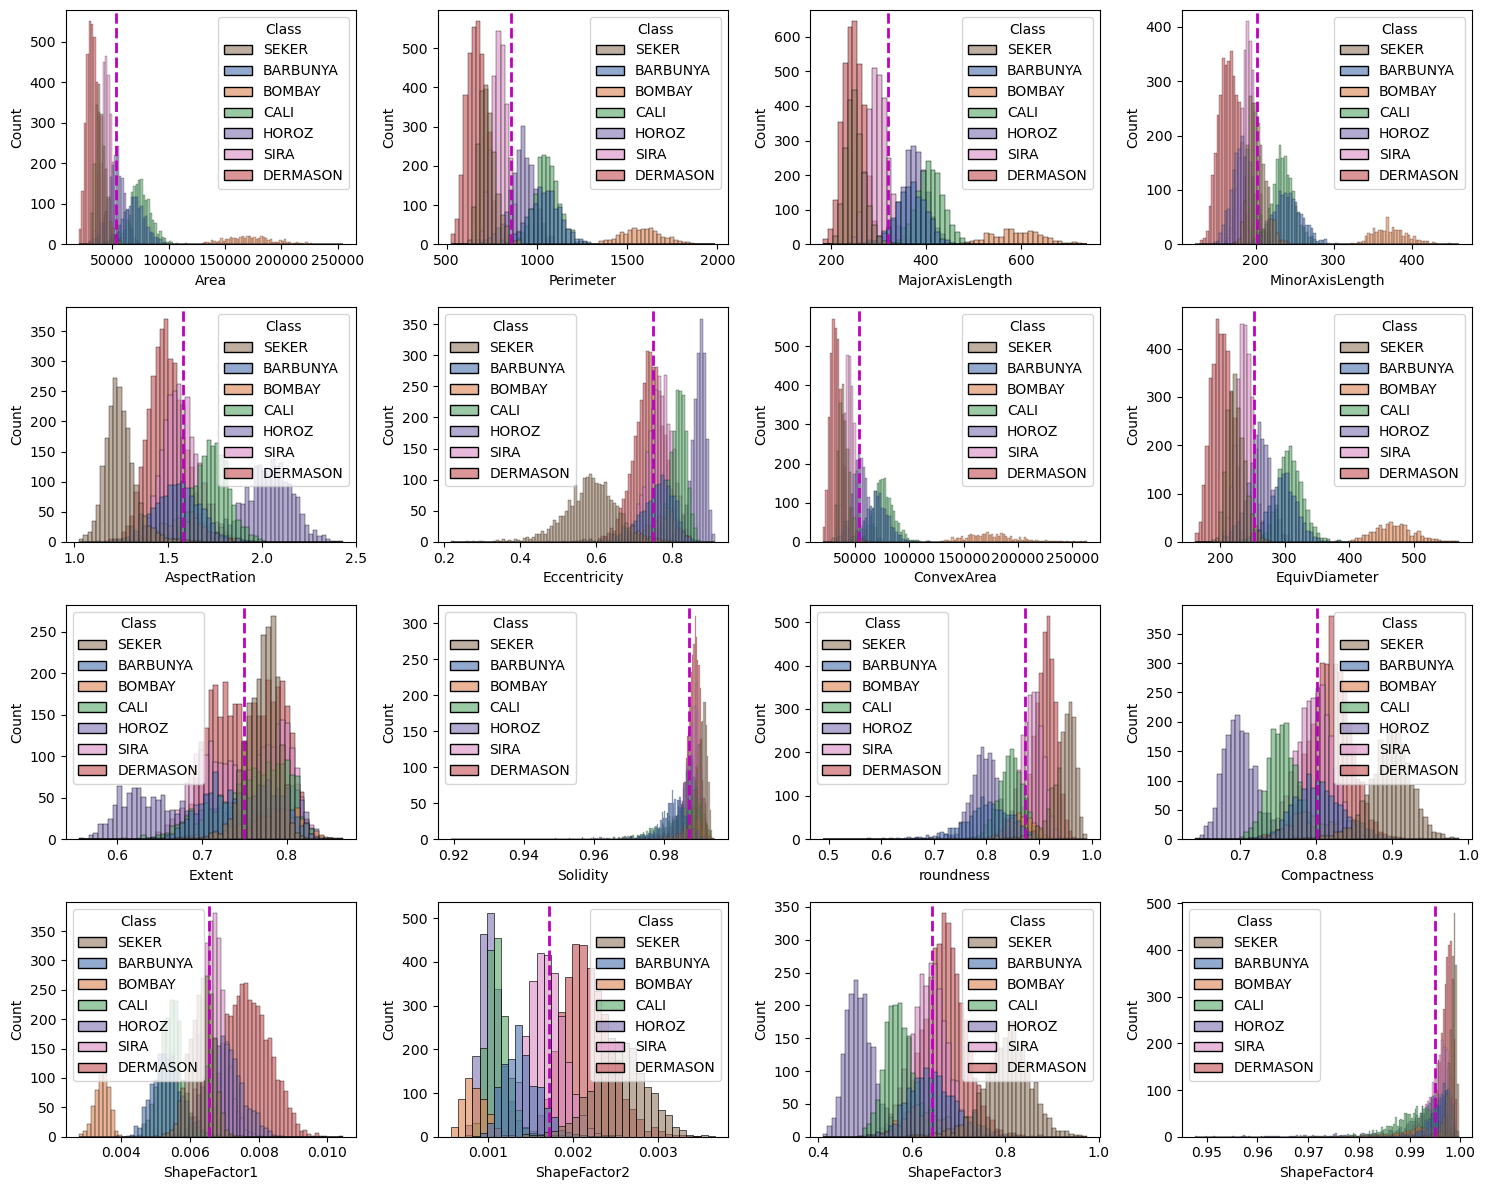

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns


unique_classes = sorted(df_beans['Class'].unique())

palette = sns.color_palette('deep', n_colors=len(unique_classes))
class_colors = dict(zip(unique_classes, palette))

numerical_cols = df_beans.drop(columns=['Class']).columns


fig, ax = plt.subplots(4, 4, figsize=(15, 12))
for variable, subplot in zip(numerical_cols, ax.flatten()):
    g = sns.histplot(data=df_beans, x=variable, ax=subplot, hue='Class', palette=class_colors,alpha=0.6)
    g.axvline(x=df_beans[variable].mean(), color='m', label='Mean', linestyle='--', linewidth=2)
plt.tight_layout()



### **The Univariate distribution per attribute for each class separately which shows that seed type BOMBAY has distinct distribution from others on several attributes**

# **Distribution of Numerical Features Across Bean Classes**

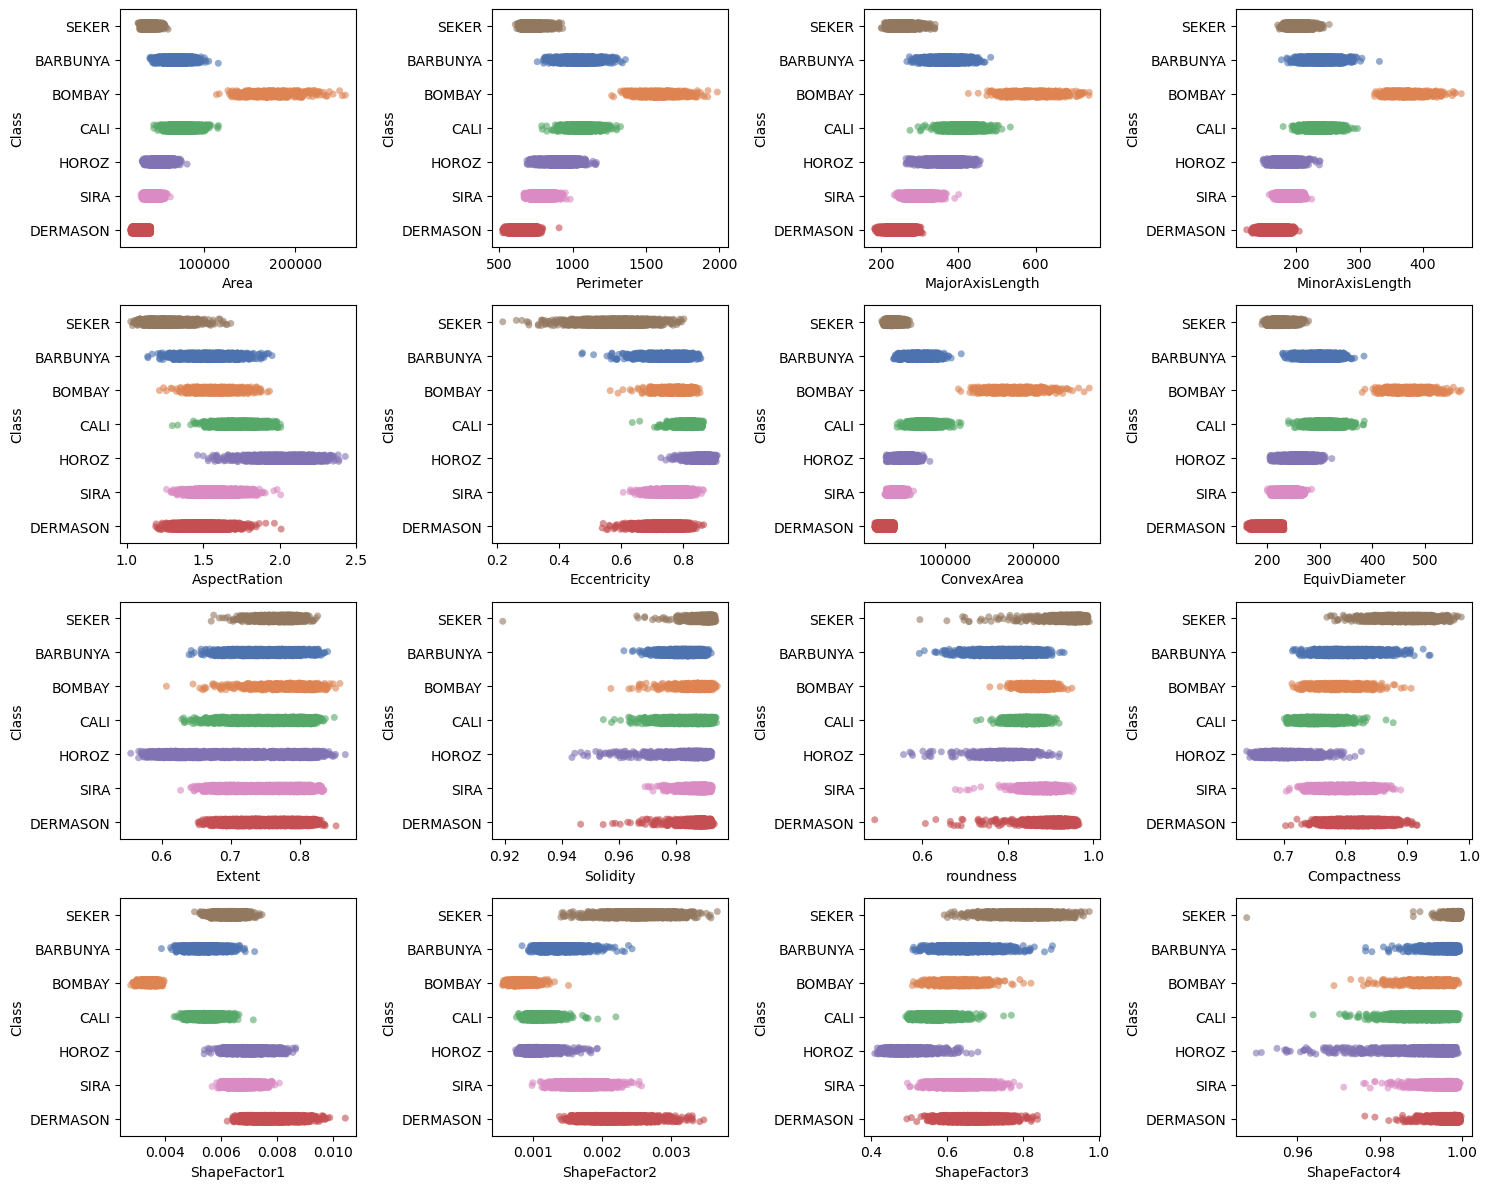

In [13]:
fig, ax = plt.subplots(4, 4, figsize=(15, 12))
for variable, subplot in zip(numerical_cols, ax.flatten()):
    g=sns.stripplot(x=df_beans[variable],y=df_beans.Class ,ax=subplot,palette=class_colors,alpha=0.6)
plt.tight_layout()

*   The distribution of BOMBAY class in many attribtes like *Area*, *MinorAxisLength*, *Convex Area*, *Minor Axis Length*, *ShapeFactor1* is well separated from other classes.
*   *Area* & Convex Area have very similar distribution across all classes indicating very high correlation.
* Distribution of *DERMASON* is very similar *SEKER* in many attributes for e.g. roundness, solidity, ShapeFactor2
* For the *extent* attribute the range of values is similar for all the bean classes

# **Correlation Matrix**

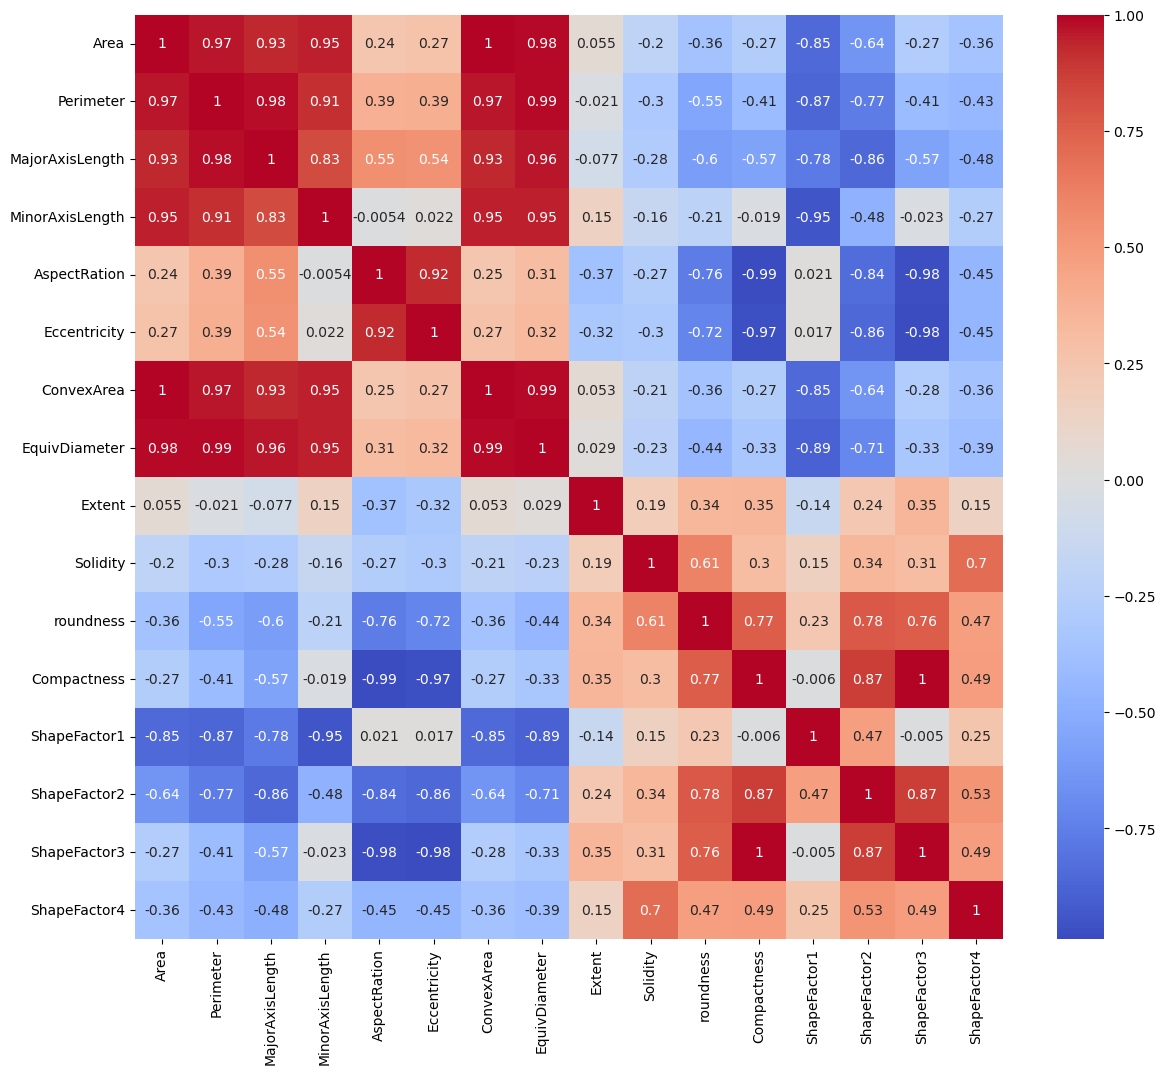

In [14]:
plt.figure(figsize=(14,12))
sns.heatmap(df_beans[numerical_cols].corr(), yticklabels='auto', annot=True, cmap='coolwarm')
plt.show()

* There a lot of highly correlated attributes in the above correlation matrix, for eg: </br>

    *   **Area & Convex Area**:1
    *   **Shaped Factor3 & Comapctness**:1
    *   **Aspect ration & compactness**: -0.99
    *   **Area & Perimeter**: 0.97
    *   **Perimeter & ShapeFactor1**: -0.87
    *   **Aspect ration & Eccentricity**: 0.92 </br>
* Some attributes with low level of correlation among them:
    *   **Extent & EquivDiameter**: 0.029
    *   **Solidity & Eccentricity**: -0.3
    *   **Compactnes & Area**: -0.27



# Pairplots Between All Numerical Features

A **pairplot** shows:
- **Diagonal**: the *univariate distribution* of each numerical feature (KDE curves).
- **Off-diagonal**: *pairwise scatter plots* between every pair of numerical features.

Why this is useful:
- To visually spot **correlations** (tight linear/curved trends).
- To see **separation between bean classes** (if `Class` is used as `hue`).
- To detect **outliers**, **skewness**, and **overlapping clusters** that may affect KMeans.

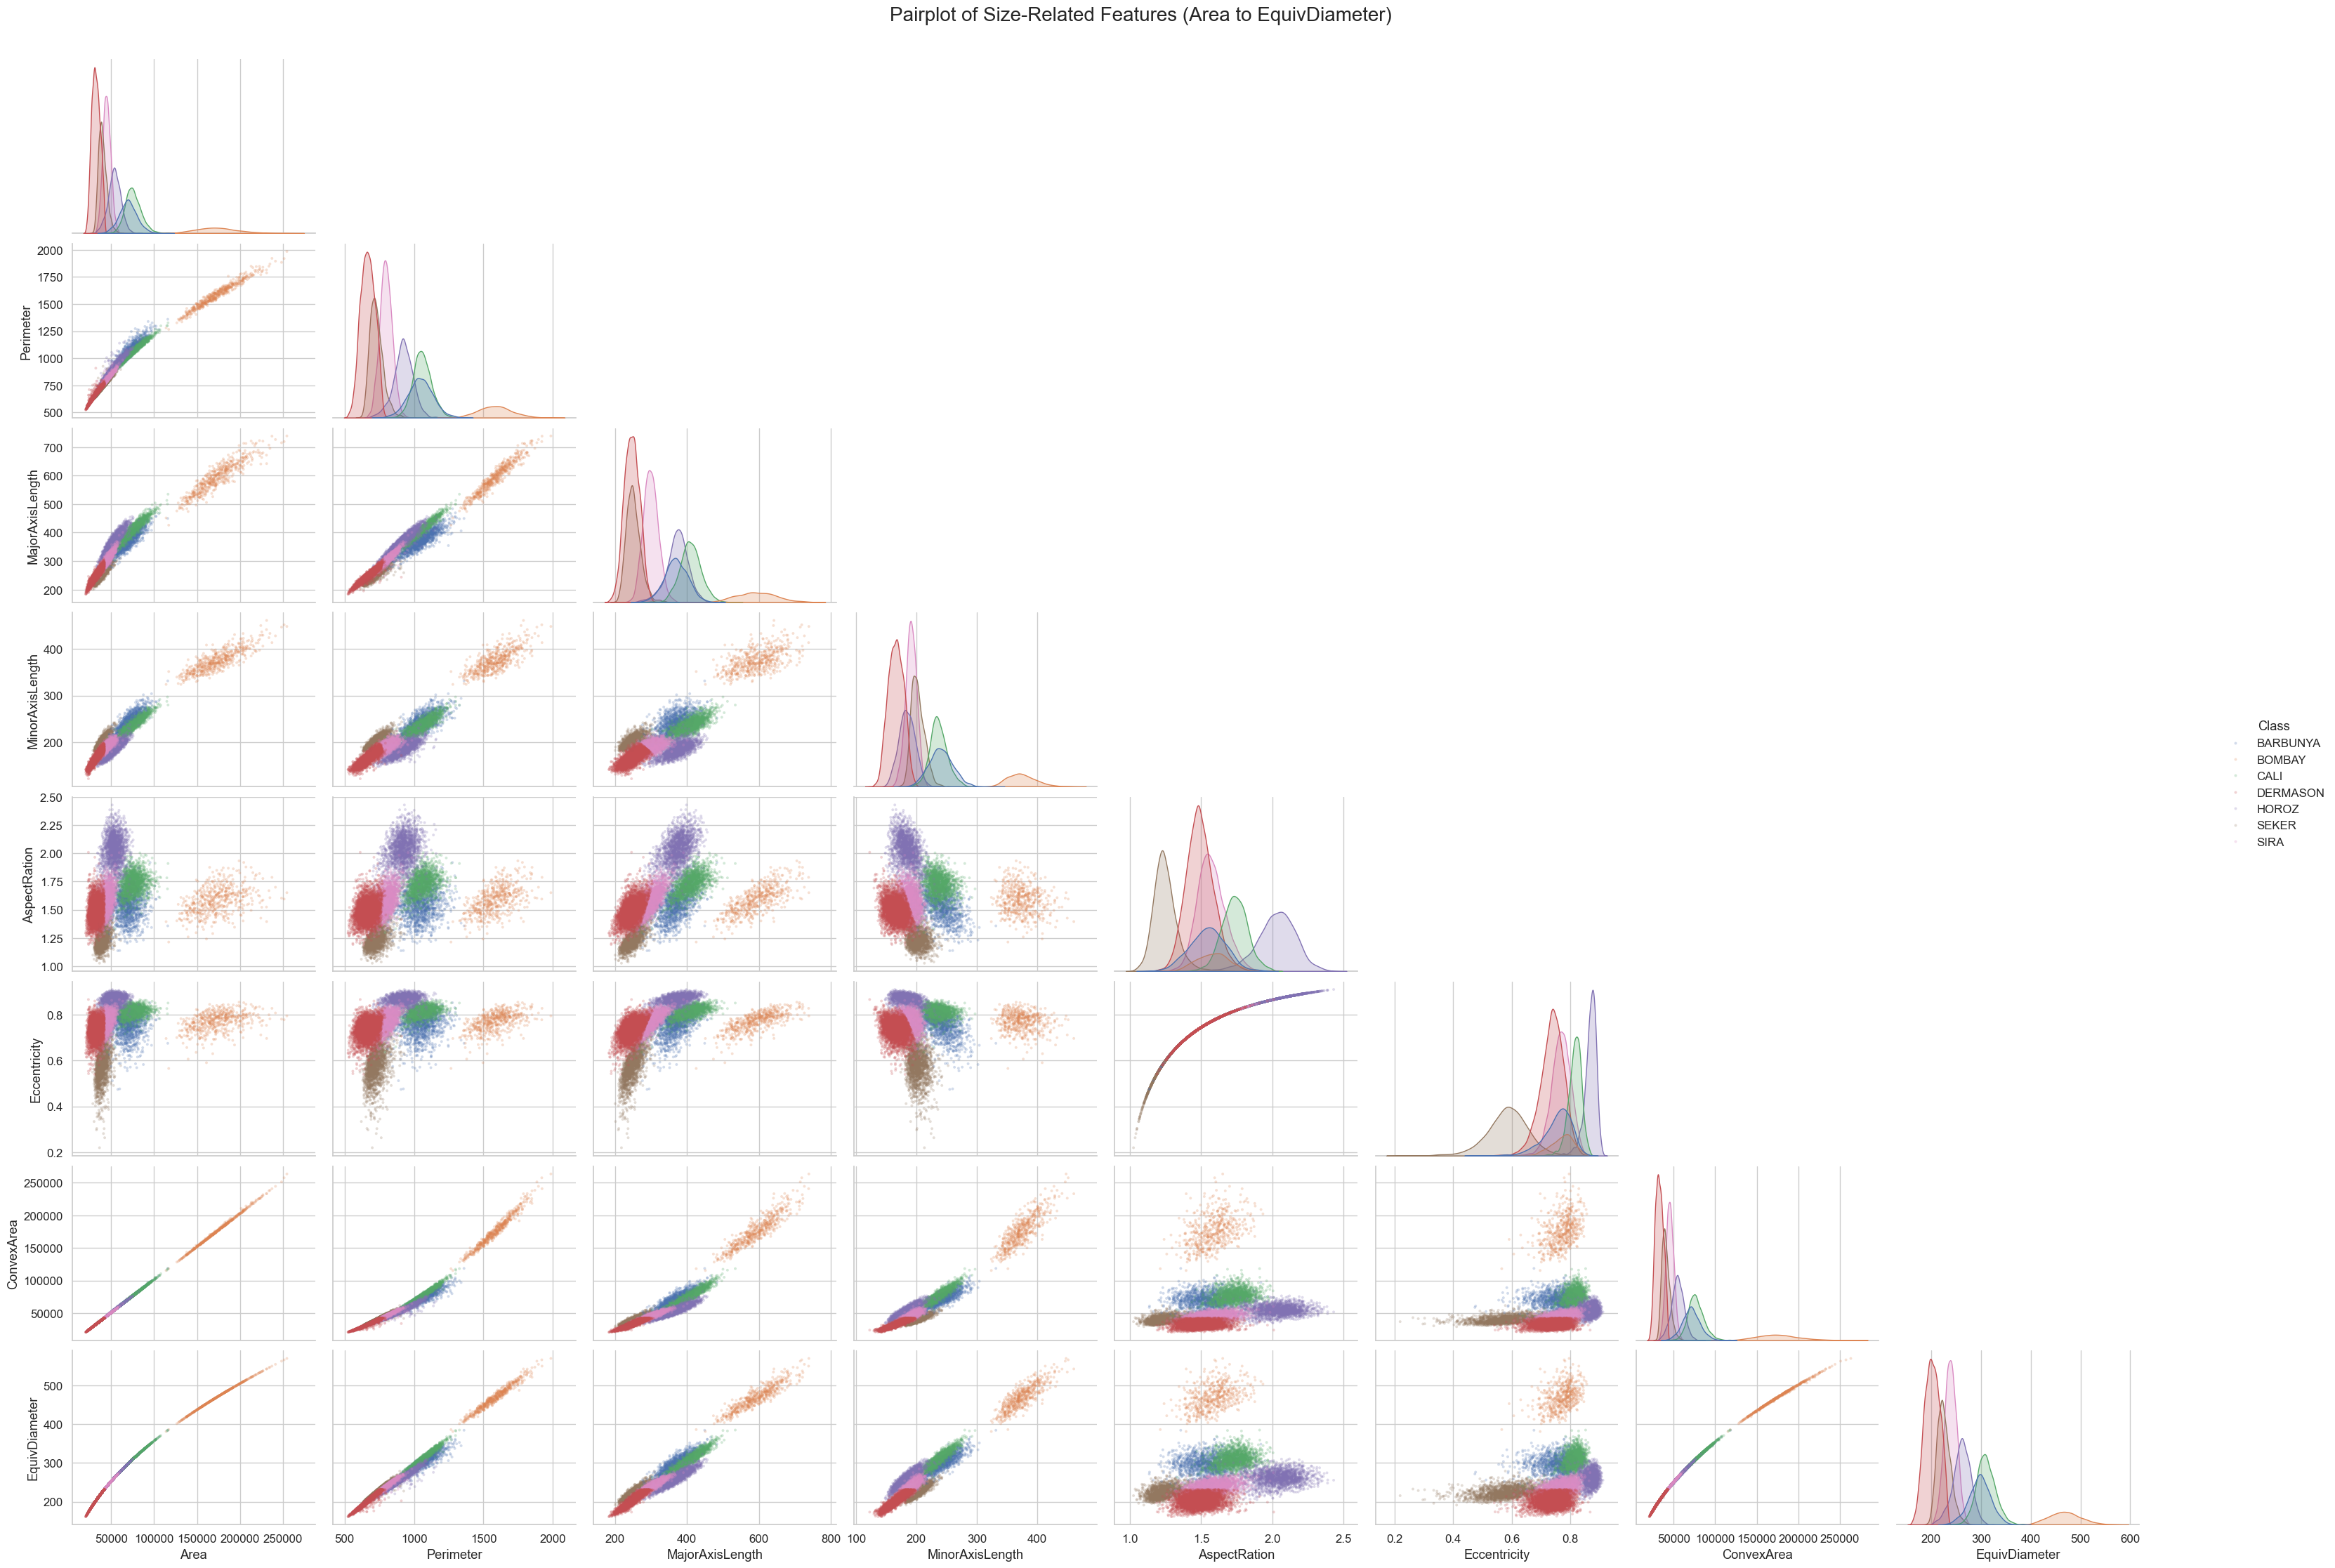

In [15]:
# Ensure Class is categorical
df_beans["Class"] = df_beans["Class"].astype("category")

size_features = [
    "Area",
    "Perimeter",
    "MajorAxisLength",
    "MinorAxisLength",
    "AspectRation",
    "Eccentricity",
    "ConvexArea",
    "EquivDiameter"
]

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

g1 = sns.pairplot(
    data=df_beans,          # FULL DATA
    vars=size_features,
    hue="Class",
    corner=True,
    diag_kind="kde",
    height=2.8,
    plot_kws=dict(
        s=8,
        alpha=0.25,
        linewidth=0
    )
)

g1.fig.set_size_inches(34, 22)
g1.fig.suptitle(
    "Pairplot of Size-Related Features (Area to EquivDiameter)",
    fontsize=20,
    y=1.02
)

# # Enlarge legend
# legend = g1._legend
# legend.set_title("Class", prop={"size": 20})

# for text in legend.get_texts():
#     text.set_fontsize(20)

# legend.set_bbox_to_anchor((1.02, 0.5))  # move legend to the right

plt.show()

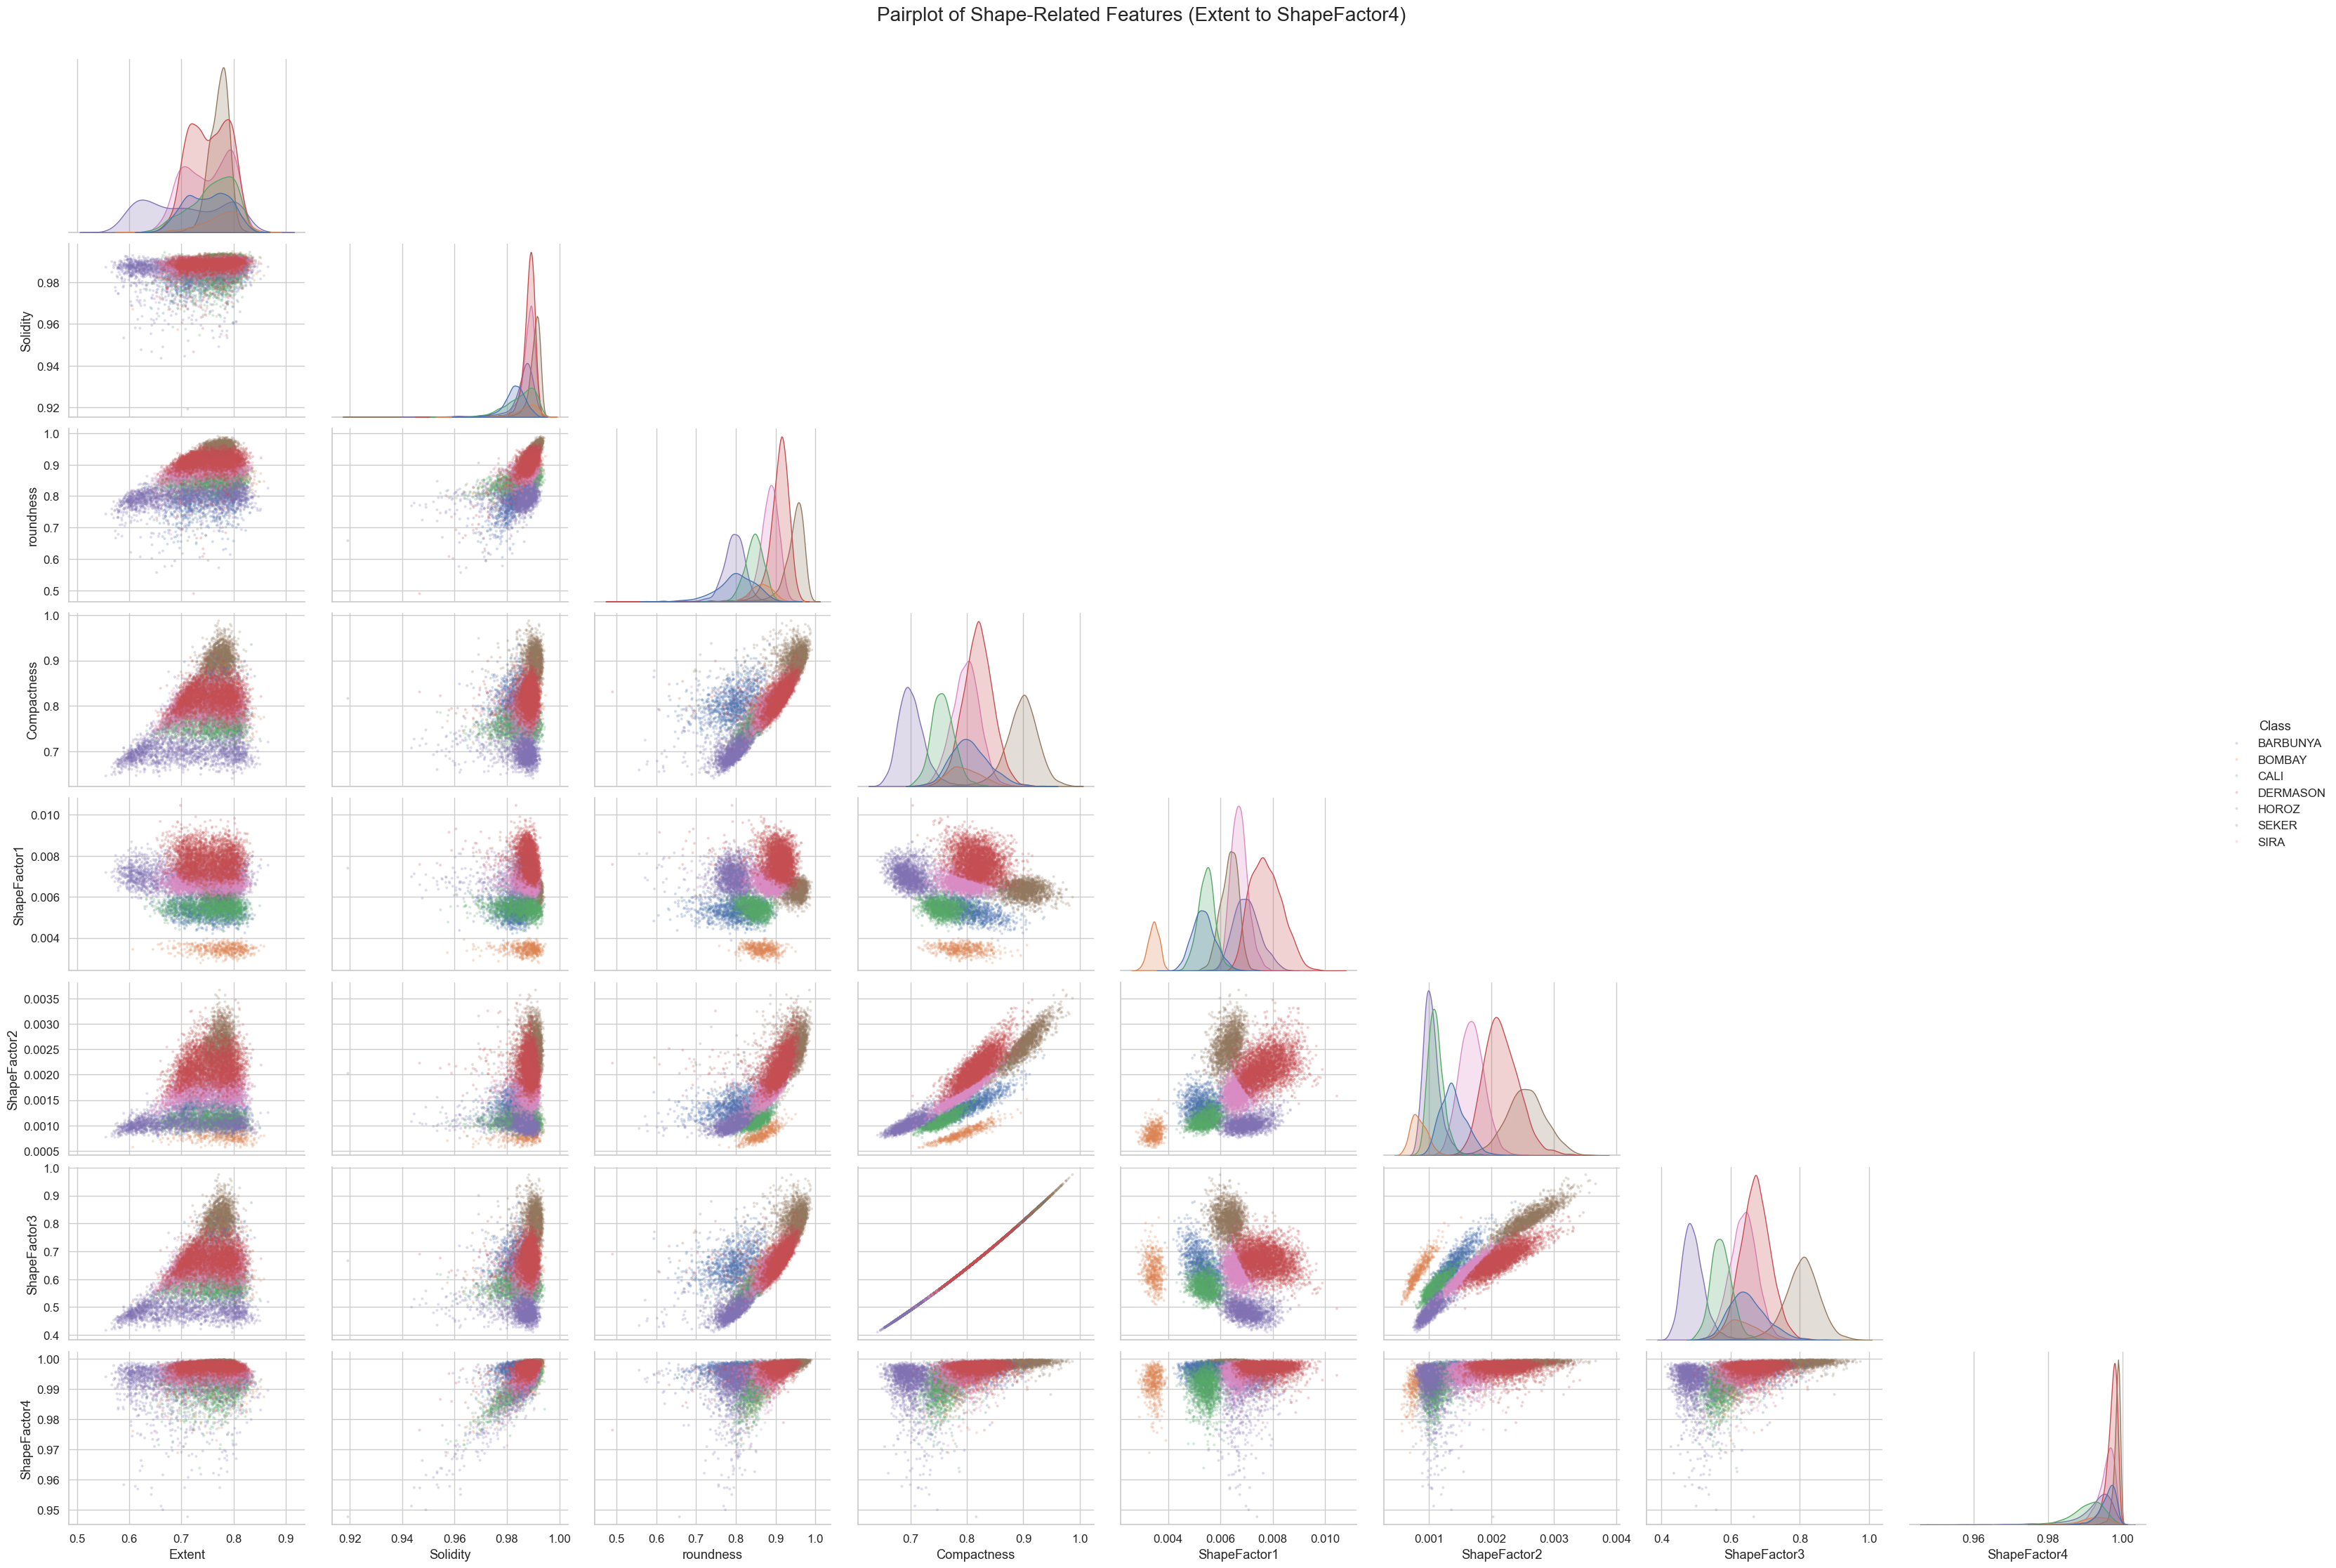

In [16]:
shape_features = [
    "Extent",
    "Solidity",
    "roundness",
    "Compactness",
    "ShapeFactor1",
    "ShapeFactor2",
    "ShapeFactor3",
    "ShapeFactor4"
]

g2 = sns.pairplot(
    data=df_beans,          # FULL DATA
    vars=shape_features,
    hue="Class",
    corner=True,
    diag_kind="kde",
    height=2.8,
    plot_kws=dict(
        s=8,
        alpha=0.25,
        linewidth=0
    )
)

g2.fig.set_size_inches(34, 22)
g2.fig.suptitle(
    "Pairplot of Shape-Related Features (Extent to ShapeFactor4)",
    fontsize=20,
    y=1.02
)

plt.show()

# **Class distribution of various types of beans**

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


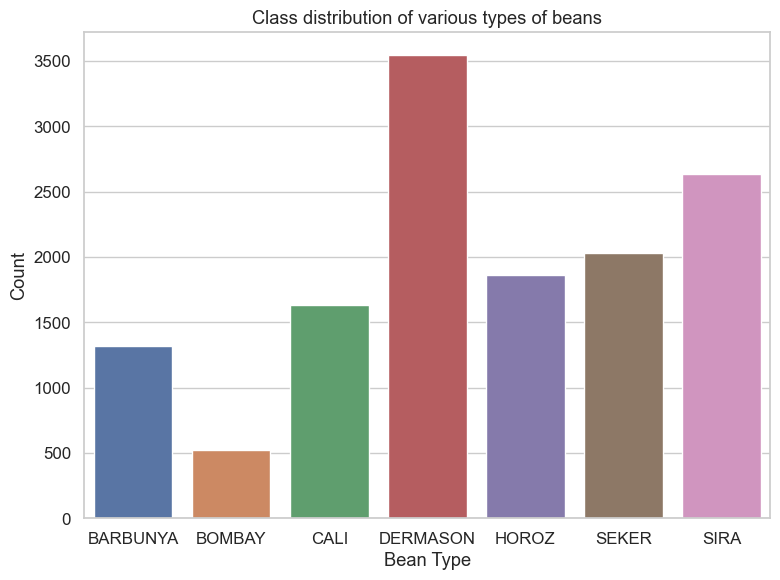

In [17]:
print(df_beans['Class'].value_counts())

plt.figure(figsize=(8,6))
sns.countplot(x='Class', data=df_beans, palette=class_colors)
plt.xlabel('Bean Type')
plt.ylabel('Count')
plt.title('Class distribution of various types of beans')
plt.tight_layout()


# **Preparing the data**

In [18]:
import numpy as np
from sklearn.preprocessing import StandardScaler


# Map bean classes to integers
class_map = {cls: idx for idx, cls in enumerate(df_beans['Class'].unique())}
df_beans['classno'] = df_beans['Class'].map(class_map)


# Extract features and true labels
X = df_beans.drop(columns=['Class', 'classno']).values

# Extract features and true labels
X = df_beans.drop(columns=['Class', 'classno']).values
y_true = df_beans['classno'].values


# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# **Determining the optimal number of clusters for KMeans using elbow method**

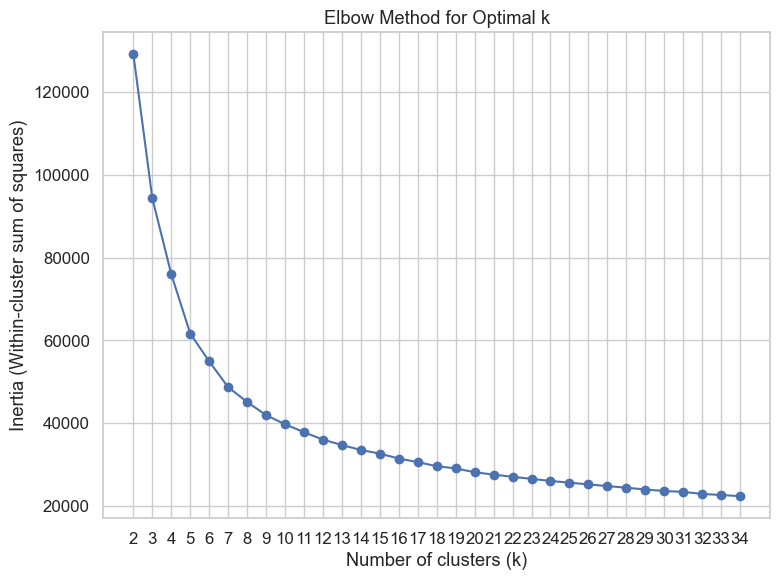

In [19]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Range of k values
k_range = range(2, 35)

# Inertia = sum of squared distances between each point and the centroid of its assigned cluster
# Store inertia (within-cluster sum of squares)
inertias = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plotting the Elbow Curve
plt.figure(figsize=(8, 6))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.grid(True)
plt.tight_layout()
plt.show()


## **We chose k = 7 because, beyond this point, the decrease in within-cluster sum of squared errors becomes slower and more gradual.**

In [20]:
# pandas Series
inertia_series = pd.Series(data=inertias, index=k_range, name='Inertia')
inertia_series.index.name = 'k (n_clusters)'

# Print
print("\nInertia values for each k:")
inertia_series[:21]


Inertia values for each k:


k (n_clusters)
2     129194.019862
3      94331.734651
4      75993.194923
5      61624.637418
6      54900.748279
7      48671.457043
8      45083.358973
9      41904.816088
10     39707.125849
11     37774.576906
12     35986.448570
13     34676.158609
14     33483.715062
15     32597.882420
16     31409.993457
17     30545.566732
18     29566.567215
19     29030.715234
20     28094.997197
21     27525.748213
22     26998.883888
Name: Inertia, dtype: float64

### **The inertia values decrease gradually after k = 7.**

# **Evaluation of KMeans Clustering (k = 7)**

In [21]:
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    rand_score, adjusted_rand_score, adjusted_mutual_info_score,homogeneity_score,
    completeness_score
)


# KMeans clustering
n_clusters = 7
kmeans = KMeans(n_clusters=n_clusters, n_init=10,random_state=2024)
y_pred = kmeans.fit_predict(X_scaled)

# Intrinsic Measures
SIL_s = silhouette_score(X_scaled, y_pred)
CH_s = calinski_harabasz_score(X_scaled, y_pred)
DB_s = davies_bouldin_score(X_scaled, y_pred)

# Extrinsic Measures
RI_s = rand_score(y_true, y_pred)
ARI_ward = adjusted_rand_score(y_true, y_pred)
AMI_ward = adjusted_mutual_info_score(y_true, y_pred)
CM_s = completeness_score(y_true, y_pred)
HM_s = homogeneity_score(y_true, y_pred)


# Print Results
print('Intrinsic Measure:\n')
print(f'Silhouette score: {SIL_s:.3f}')
print(f'Calinski and Harabasz score: {CH_s:.3f}')
print(f'Davies-Bouldin score: {DB_s:.3f}')
#############################################

print('\nExtrinsic Measure:\n')
print(f'Random index: {RI_s:.3f}')
print(f'Homogeneity score: {HM_s:.3f}')
print(f'Completeness score: {CM_s:.3f}')
print(f'Adjusted Random index: {ARI_ward:.3f}')
print(f'Adjusted Mutual Information: {AMI_ward:.3f}')

Intrinsic Measure:

Silhouette score: 0.309
Calinski and Harabasz score: 7787.837
Davies-Bouldin score: 1.102

Extrinsic Measure:

Random index: 0.903
Homogeneity score: 0.703
Completeness score: 0.722
Adjusted Random index: 0.667
Adjusted Mutual Information: 0.712


##  Standard behaviour of the cluster validity indices used
### **Intrinsic Measure:** These metrics evaluate the quality of clustering using only the data features, without referring to ground-truth labels, by measuring how compact each cluster is and how far apart the clusters are from each other.
* **Silhouette Score** measures how well each point fits within its own cluster compared to other clusters. It ranges from −1 to +1, with higher values indicating better-defined and more distinct clusters.
* **Calinski-Harabasz Score** measures how compact the points are within each cluster and how far apart the clusters are from each other. Its typical range is from zero to infinity, with higher values indicating better clustering through tightly grouped points and well-separated clusters.
*  **Davies-Bouldin Score** measures the average similarity between each cluster and its most similar one, based on cluster size and distance.It ranges from 0 to infinity, with lower values indicating better clustering through compact, well-separated clusters.




## **Extrinsic measure:** These metrics evaluate the quality of clustering by comparing the predicted cluster labels to the true class labels, assessing how well the clustering aligns with the actual ground truth.
* **Random Index** measures the similarity between predicted cluster labels and true labels by counting how many pairs of samples are assigned consistently.
It ranges from 0 to 1, with higher values indicating better agreement between clustering and ground truth.
* **Homogeneity Score** measures whether each cluster contains only data points from a single class. It ranges from 0 to 1, with 1 indicating that all clusters are perfectly pure with respect to the true labels.
* **Completeness Score** measures whether all data points of a given class are assigned to the same cluster. It ranges from 0 to 1, with 1 indicating that each class’s samples are entirely grouped within a single cluster.
* **Adjusted Rand Index** measures the similarity between predicted clusters and true labels, while correcting for chance groupings. Unlike the regular Random Index, which can be artificially high due to random matches, ARI accounts for this and gives a value between −1 and 1, where 1 indicates perfect agreement, 0 indicates random labeling, and negative values mean worse than random clustering.
* **Adjusted Mutual Information** measures the amount of shared information between predicted clusters and true labels, adjusted for chance.
It ranges from 0 to 1 (or slightly negative in rare cases), where higher values indicate better agreement between the clustering and the ground truth, and the adjustment ensures the score isn't inflated by random labelings.

# **Visualization of samples grouped by actual bean types and cluster labels**

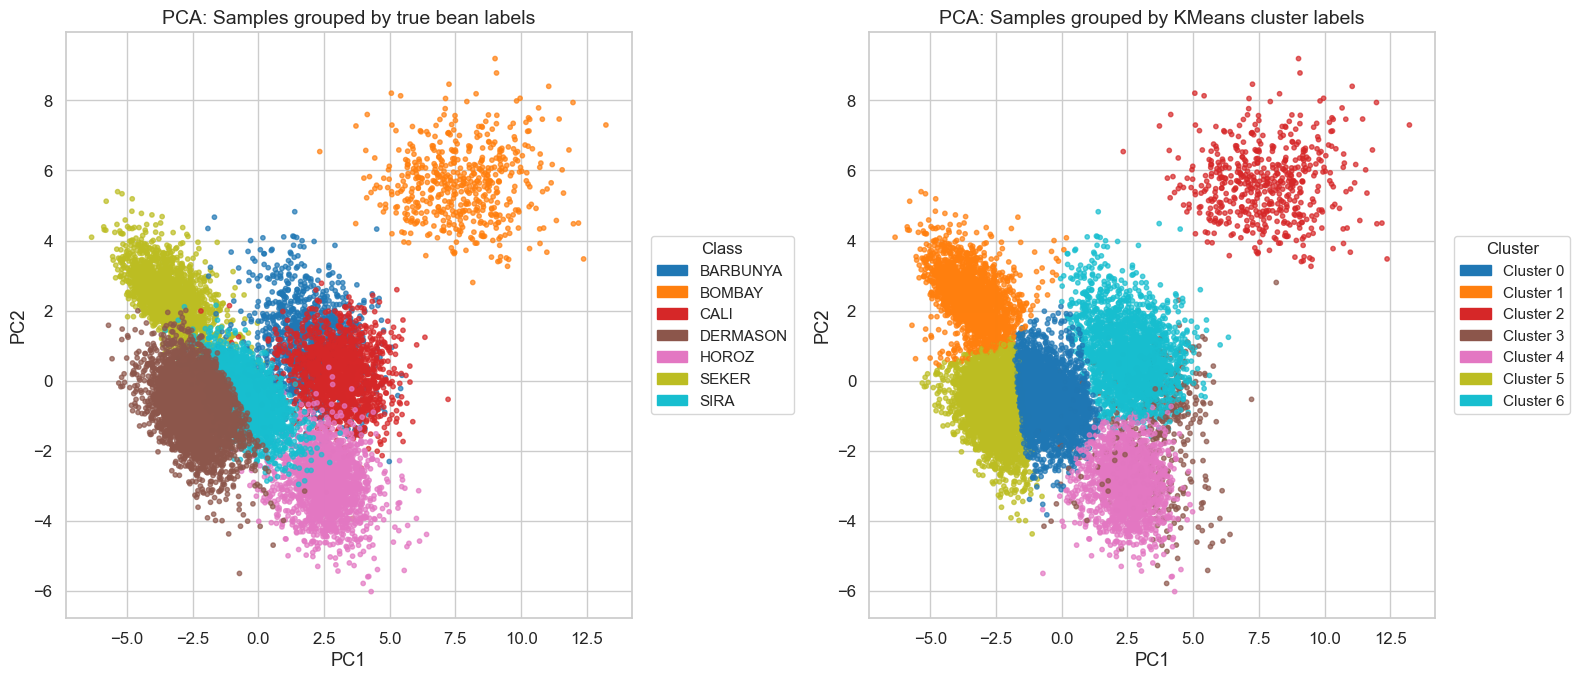

Explained variance ratio: [0.55546808 0.26360789]
Total variance explained by PC1+PC2: 0.8190759716525315


In [22]:
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

# Assume:
# - df_beans["Class"] exists (string labels)
# - X_scaled exists (scaled numeric features)
# - y_pred exists (KMeans predicted cluster labels)

class_labels = df_beans["Class"].values

# Fit PCA -> 2 components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Map class names to integers for coloring
unique_classes = np.unique(class_labels)
class_to_color = {cls: i for i, cls in enumerate(unique_classes)}
y_true_named = np.array([class_to_color[cls] for cls in class_labels])

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: True labels with proper class names
scatter0 = axes[0].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=y_true_named, cmap="tab10", s=10, alpha=0.7
)
axes[0].set_title("PCA: Samples grouped by true bean labels", fontsize=14)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

handles0 = [
    mpatches.Patch(color=scatter0.cmap(scatter0.norm(i)), label=cls)
    for i, cls in enumerate(unique_classes)
]
axes[0].legend(
    handles=handles0,
    title="Class",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=11,
    title_fontsize=12,
    frameon=True
)

# Right: KMeans cluster labels
scatter1 = axes[1].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=y_pred, cmap="tab10", s=10, alpha=0.7
)
axes[1].set_title("PCA: Samples grouped by KMeans cluster labels", fontsize=14)
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

unique_clusters = np.unique(y_pred)
handles1 = [
    mpatches.Patch(color=scatter1.cmap(scatter1.norm(i)), label=f"Cluster {i}")
    for i in unique_clusters
]
axes[1].legend(
    handles=handles1,
    title="Cluster",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=11,
    title_fontsize=12,
    frameon=True
)

plt.tight_layout()
plt.show()

# Optional: print explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained by PC1+PC2:", pca.explained_variance_ratio_.sum())


* KMeans has formed distinct clusters that broadly correspond to the true bean classes.
* The overall cluster arrangement visually resembles the true class distribution in the reduced 2D space.
* Some clusters show mixing (**BARBUNYA and CALI**), indicating difficulty in separating bean types with similar physical features.
* The clustering is effective, though overlaps between true labels and predicted clusters still remain.




# **Evaluation of KMeans Clustering (k = 6)**

In [23]:
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    rand_score, adjusted_rand_score, adjusted_mutual_info_score,homogeneity_score,
    completeness_score
)


# KMeans clustering
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, n_init=10,random_state=2024)
y_pred = kmeans.fit_predict(X_scaled)

# Intrinsic Measures
SIL_s = silhouette_score(X_scaled, y_pred)
CH_s = calinski_harabasz_score(X_scaled, y_pred)
DB_s = davies_bouldin_score(X_scaled, y_pred)

# Extrinsic Measures
RI_s = rand_score(y_true, y_pred)
ARI_ward = adjusted_rand_score(y_true, y_pred)
AMI_ward = adjusted_mutual_info_score(y_true, y_pred)
CM_s = completeness_score(y_true, y_pred)
HM_s = homogeneity_score(y_true, y_pred)


# Print Results
print('Intrinsic Measure:\n')
print(f'Silhouette score: {SIL_s:.3f}')
print(f'Calinski and Harabasz score: {CH_s:.3f}')
print(f'Davies-Bouldin score: {DB_s:.3f}')
#############################################

print('\nExtrinsic Measure:\n')
print(f'Random index: {RI_s:.3f}')
print(f'Homogeneity score: {HM_s:.3f}')
print(f'Completeness score: {CM_s:.3f}')
print(f'Adjusted Random index: {ARI_ward:.3f}')
print(f'Adjusted Mutual Information: {AMI_ward:.3f}')

Intrinsic Measure:

Silhouette score: 0.360
Calinski and Harabasz score: 7978.453
Davies-Bouldin score: 0.996

Extrinsic Measure:

Random index: 0.839
Homogeneity score: 0.603
Completeness score: 0.736
Adjusted Random index: 0.540
Adjusted Mutual Information: 0.663


# **Visualization of samples grouped by actual bean types and cluster labels**

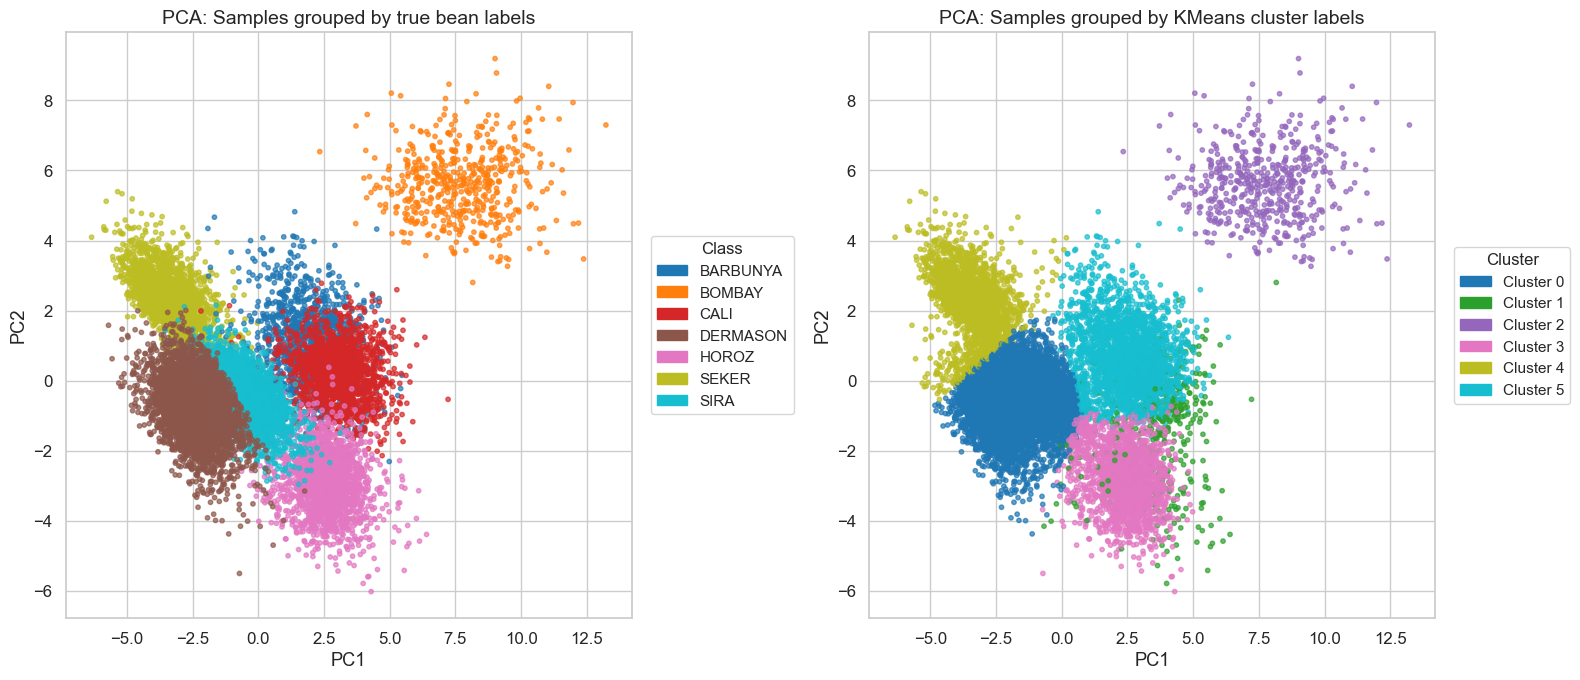

Explained variance ratio: [0.55546808 0.26360789]
Total variance explained by PC1+PC2: 0.8190759716525315


In [24]:
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

# Assume:
# - df_beans["Class"] exists (string labels)
# - X_scaled exists (scaled numeric features)
# - y_pred exists (KMeans predicted cluster labels)

class_labels = df_beans["Class"].values

# Fit PCA -> 2 components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Map class names to integers for coloring
unique_classes = np.unique(class_labels)
class_to_color = {cls: i for i, cls in enumerate(unique_classes)}
y_true_named = np.array([class_to_color[cls] for cls in class_labels])

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: True labels with proper class names
scatter0 = axes[0].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=y_true_named, cmap="tab10", s=10, alpha=0.7
)
axes[0].set_title("PCA: Samples grouped by true bean labels", fontsize=14)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

handles0 = [
    mpatches.Patch(color=scatter0.cmap(scatter0.norm(i)), label=cls)
    for i, cls in enumerate(unique_classes)
]
axes[0].legend(
    handles=handles0,
    title="Class",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=11,
    title_fontsize=12,
    frameon=True
)

# Right: KMeans cluster labels
scatter1 = axes[1].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=y_pred, cmap="tab10", s=10, alpha=0.7
)
axes[1].set_title("PCA: Samples grouped by KMeans cluster labels", fontsize=14)
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

unique_clusters = np.unique(y_pred)
handles1 = [
    mpatches.Patch(color=scatter1.cmap(scatter1.norm(i)), label=f"Cluster {i}")
    for i in unique_clusters
]
axes[1].legend(
    handles=handles1,
    title="Cluster",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=11,
    title_fontsize=12,
    frameon=True
)

plt.tight_layout()
plt.show()

# Optional: print explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained by PC1+PC2:", pca.explained_variance_ratio_.sum())

# **Evaluation of KMeans Clustering (k = 8)**

In [25]:
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    rand_score, adjusted_rand_score, adjusted_mutual_info_score,homogeneity_score,
    completeness_score
)


# KMeans clustering
n_clusters = 8
kmeans = KMeans(n_clusters=n_clusters, n_init=10,random_state=2024)
y_pred = kmeans.fit_predict(X_scaled)

# Intrinsic Measures
SIL_s = silhouette_score(X_scaled, y_pred)
CH_s = calinski_harabasz_score(X_scaled, y_pred)
DB_s = davies_bouldin_score(X_scaled, y_pred)

# Extrinsic Measures
RI_s = rand_score(y_true, y_pred)
ARI_ward = adjusted_rand_score(y_true, y_pred)
AMI_ward = adjusted_mutual_info_score(y_true, y_pred)
CM_s = completeness_score(y_true, y_pred)
HM_s = homogeneity_score(y_true, y_pred)


# Print Results
print('Intrinsic Measure:\n')
print(f'Silhouette score: {SIL_s:.3f}')
print(f'Calinski and Harabasz score: {CH_s:.3f}')
print(f'Davies-Bouldin score: {DB_s:.3f}')
#############################################

print('\nExtrinsic Measure:\n')
print(f'Random index: {RI_s:.3f}')
print(f'Homogeneity score: {HM_s:.3f}')
print(f'Completeness score: {CM_s:.3f}')
print(f'Adjusted Random index: {ARI_ward:.3f}')
print(f'Adjusted Mutual Information: {AMI_ward:.3f}')

Intrinsic Measure:

Silhouette score: 0.303
Calinski and Harabasz score: 7359.860
Davies-Bouldin score: 1.158

Extrinsic Measure:

Random index: 0.915
Homogeneity score: 0.746
Completeness score: 0.718
Adjusted Random index: 0.697
Adjusted Mutual Information: 0.732


# **Visualization of samples grouped by actual bean types and cluster labels**

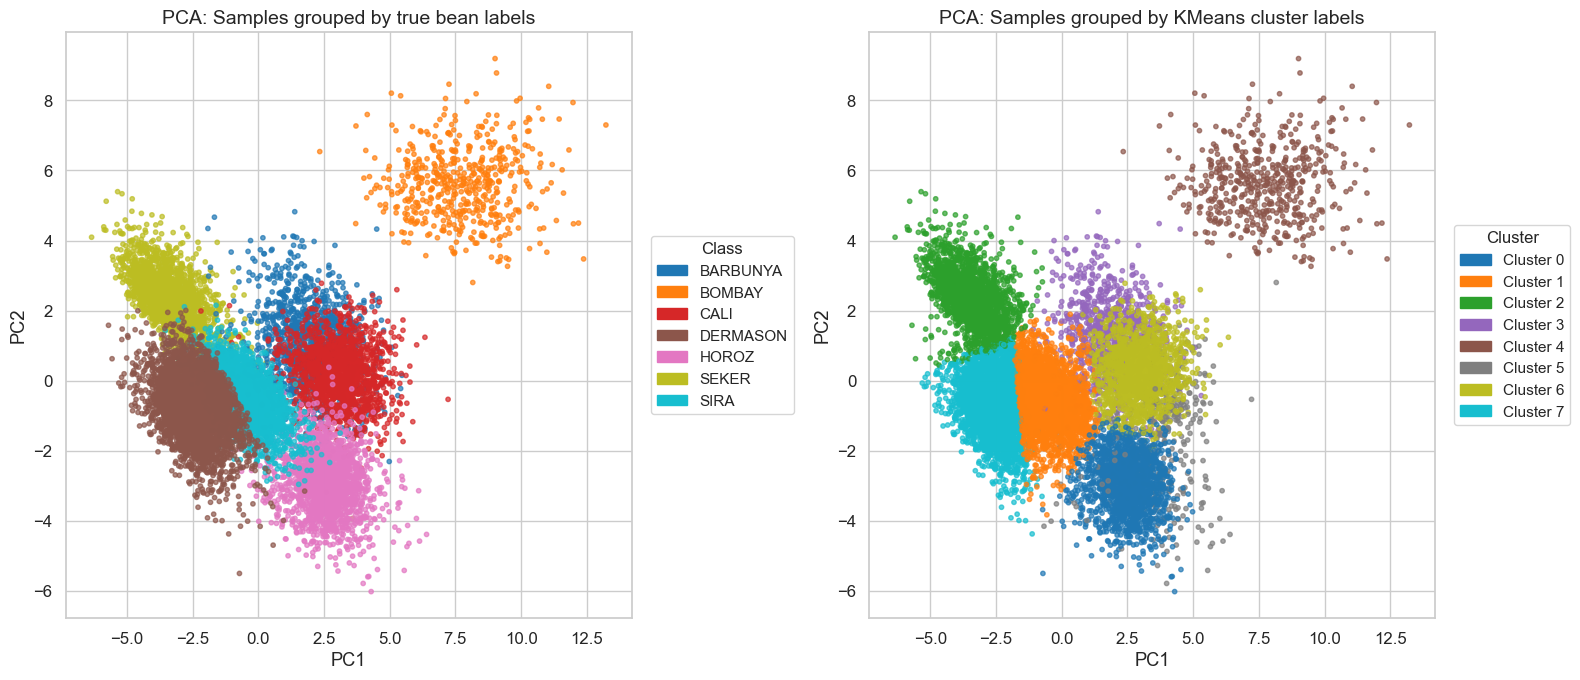

Explained variance ratio: [0.55546808 0.26360789]
Total variance explained by PC1+PC2: 0.8190759716525315


In [26]:
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

# Assume:
# - df_beans["Class"] exists (string labels)
# - X_scaled exists (scaled numeric features)
# - y_pred exists (KMeans predicted cluster labels)

class_labels = df_beans["Class"].values

# Fit PCA -> 2 components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Map class names to integers for coloring
unique_classes = np.unique(class_labels)
class_to_color = {cls: i for i, cls in enumerate(unique_classes)}
y_true_named = np.array([class_to_color[cls] for cls in class_labels])

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: True labels with proper class names
scatter0 = axes[0].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=y_true_named, cmap="tab10", s=10, alpha=0.7
)
axes[0].set_title("PCA: Samples grouped by true bean labels", fontsize=14)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

handles0 = [
    mpatches.Patch(color=scatter0.cmap(scatter0.norm(i)), label=cls)
    for i, cls in enumerate(unique_classes)
]
axes[0].legend(
    handles=handles0,
    title="Class",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=11,
    title_fontsize=12,
    frameon=True
)

# Right: KMeans cluster labels
scatter1 = axes[1].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=y_pred, cmap="tab10", s=10, alpha=0.7
)
axes[1].set_title("PCA: Samples grouped by KMeans cluster labels", fontsize=14)
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

unique_clusters = np.unique(y_pred)
handles1 = [
    mpatches.Patch(color=scatter1.cmap(scatter1.norm(i)), label=f"Cluster {i}")
    for i in unique_clusters
]
axes[1].legend(
    handles=handles1,
    title="Cluster",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=11,
    title_fontsize=12,
    frameon=True
)

plt.tight_layout()
plt.show()

# Optional: print explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained by PC1+PC2:", pca.explained_variance_ratio_.sum())

# **Comparison of Kmeans performance at k=6,7 and 8**

In [27]:

data = {
    'k': [6, 7, 8],
    'Silhouette': [0.360, 0.309, 0.303],
    'Calinski-Harabas': [7978.453, 7787.837, 7359.860],
    'Davies-Bouldin': [0.996, 1.102, 1.158],
    'Rand Index': [0.839, 0.903, 0.915],
    'Homogeneity': [0.603, 0.703, 0.746],
    'Completeness': [0.736, 0.722, 0.718],
    'Adjusted Rand': [0.540, 0.667, 0.697],
    'Adjusted Mutual Info': [0.663, 0.712, 0.732]
}

#
df_metrics = pd.DataFrame(data)
df_metrics.set_index('k', inplace=True)


df_metrics


,Silhouette,Calinski-Harabas,Davies-Bouldin,Rand Index,Homogeneity,Completeness,Adjusted Rand,Adjusted Mutual Info
k,,,,,,,,
6,0.360,7978.453,0.996,0.839,0.603,0.736,0.540,0.663
7,0.309,7787.837,1.102,0.903,0.703,0.722,0.667,0.712
8,0.303,7359.860,1.158,0.915,0.746,0.718,0.697,0.732



* **k = 6**   Intrinsic measures are strongest, indicating well-separated and compact clusters. Extrinsic scores are moderate, suggesting only partial alignment with the true class labels.

* **k = 7** Intrinsic quality slightly declines but remains reasonable.
  Extrinsic metrics improve overall, showing better correspondence with true labels.

* **k = 8** Intrinsic clustering degrades further, though not drastically. Extrinsic scores are highest, as clusters become purer with respect to class labels.

